<a href="https://colab.research.google.com/github/itsmeyessir/CCDATSCL_EXERCISES_COM222-ML/blob/main/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

In this activity, you will work with the New York City Airbnb Open Data—a popular, messy, and highly realistic dataset used by data analysts and data scientists around the world. The dataset includes thousands of Airbnb listings along with details about hosts, locations, prices, reviews, and more.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR8Pmq3Gv7y7z_2Xun-OqMIk43kd5u0TXEatw&s"/>


To guide your work, you will follow the 6-Step Data Wrangling Process, a professional workflow used in industry:

- Discovering. Become familiar with the data by exploring its structure and observing patterns.

- Structuring. Fix issues related to format, column types, indices, and duplicated records.

- Cleaning. Handle missing values, outliers, and inconsistencies so the dataset becomes trustworthy.

- Enriching. Add new features, aggregate information, and enhance the dataset for deeper insights.

- Validating. Apply rule-based checks to ensure the data meets quality standards.

- Publishing. Export and prepare the cleaned dataset for downstream analysis or reporting.
Throughout this exercise, you will answer questions and fill in code cells based on these six steps. You will mimic what professional data scientists do when preparing data for business intelligence dashboards, machine learning models, or exploratory analysis.

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data
True


## A. Discovering


Display the first 10 rows

In [2]:
# put your answer here
import pandas as pd

df = pd.read_csv(mydataset)

df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


Display the column names:

In [3]:
# put your answer here
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Display the dataframe shape:

In [4]:
# put your answer here
df.shape

(48895, 16)

Identify the numerical features:

In [5]:
# put your answer here
numerical_df = df.select_dtypes(include='number')
print(numerical_df.head())

     id  host_id  latitude  longitude  price  minimum_nights  \
0  2539     2787  40.64749  -73.97237    149               1   
1  2595     2845  40.75362  -73.98377    225               1   
2  3647     4632  40.80902  -73.94190    150               3   
3  3831     4869  40.68514  -73.95976     89               1   
4  5022     7192  40.79851  -73.94399     80              10   

   number_of_reviews  reviews_per_month  calculated_host_listings_count  \
0                  9               0.21                               6   
1                 45               0.38                               2   
2                  0                NaN                               1   
3                270               4.64                               1   
4                  9               0.10                               1   

   availability_365  
0               365  
1               355  
2               365  
3               194  
4                 0  


In [6]:
print(numerical_df.describe())

                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1.680442   
min          1.000000           0.00

In [7]:
print(numerical_df.columns.tolist())

['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [8]:
print(df['price'].head())

0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64


Identify the categorical features

In [9]:
# put your answer here
categorical_cols_object = df.select_dtypes(include='object').columns
print("Categorical columns (object dtype):", categorical_cols_object)

Categorical columns (object dtype): Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')


In [10]:
categorical_cols_category = df.select_dtypes(include='category').columns
print("Categorical columns (category dtype):", categorical_cols_category)

Categorical columns (category dtype): Index([], dtype='object')


In [11]:
print("\nValue counts for 'Neighbourhood Group':")
print(df['neighbourhood_group'].value_counts())


Value counts for 'Neighbourhood Group':
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


In [12]:
print("\nValue counts for 'Room Type':")
print(df['room_type'].value_counts())


Value counts for 'Room Type':
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


What are the top 5 questions this dataset might help answer?

In [13]:
# put your answer here

question_list = ["1. What is the distribution of price for different room_type categories?",
"2. Are there any correlations between number_of_reviews, reviews_per_month, and price?",
"3. Which neighbourhood_group has the highest average price and availability_365?",
"4. How many unique host_ids are there, and how many of them have multiple listings (calculated_host_listings_count > 1)?",
"5. What is the impact of minimum_nights on the price of a listing?"]

print(*question_list, sep='\n')

1. What is the distribution of price for different room_type categories?
2. Are there any correlations between number_of_reviews, reviews_per_month, and price?
3. Which neighbourhood_group has the highest average price and availability_365?
4. How many unique host_ids are there, and how many of them have multiple listings (calculated_host_listings_count > 1)?
5. What is the impact of minimum_nights on the price of a listing?


## B. Structuring

Check if the dataset has proper column types

In [14]:
# put your answer here
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


Check if the dataset has index issues

In [15]:
# put your answer here
df.index

RangeIndex(start=0, stop=48895, step=1)

Check if the dataset has duplicated rows

In [16]:
# put your answer here
df.duplicated().sum()

np.int64(0)

Convert columns to correct types (e.g., dates → datetime).

In [17]:
# put your answer here
df['last_review'] = pd.to_datetime(df['last_review'])
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


Identify at least one structural issue and describe how to fix it.

In [18]:
# put your answer here

for col in ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [19]:
# in the code cell above, i decided to convert suitable object columns to 'category' dtype
# so that we can optimize memory usage and improve performance.
df.dtypes

,0
id,int64
name,category
host_id,int64
host_name,category
neighbourhood_group,category
neighbourhood,category
latitude,float64
longitude,float64
room_type,category
price,int64


In [20]:
# another structural issue that we addressed earlier is by converting last_review column
# from object (string) to datetime. we fixed it by doing:

# df['last_review'] = pd.to_datetime(df['last_review']) nagawa na natin kanina
df.dtypes

,0
id,int64
name,category
host_id,int64
host_name,category
neighbourhood_group,category
neighbourhood,category
latitude,float64
longitude,float64
room_type,category
price,int64


Explanation of Fix:

pd.to_datetime() is a pandas function designed to convert argument to datetime and this conversion allows us to do proper chronological ordering, time-based calculations, and ensures consistency with other potential date columns.
After conversion, the df.dtypes output confirmed that last_review is now of datetime64[ns] type, indicating a successful structural correction.

## C. Cleaning



Check for missing values

In [21]:
# put your answer here
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Check for outliers in `minimum_nights`

In [22]:
# put your answer here
df['minimum_nights'].describe()

,minimum_nights
count,48895.000000
mean,7.029962
std,20.510550
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1250.000000


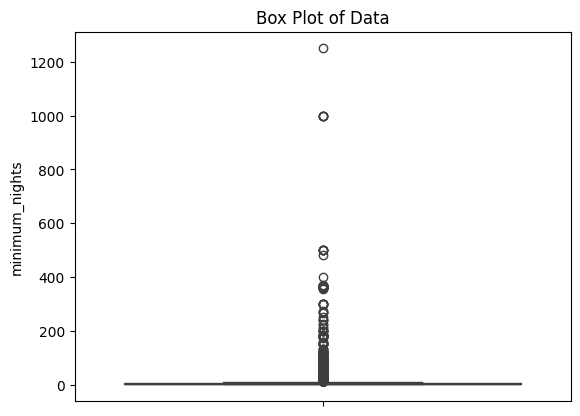

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(y=df['minimum_nights'])
plt.title('Box Plot of Data')
plt.show()

Check for invalid values (e.g., price ≤ 0)

In [24]:
# put your answer here
df[df['price'] <= 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaT,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [25]:
# checking for minimum_nights less than or equal to 0
invalid_min_nights = df[df['minimum_nights'] <= 0]
print(f"Listings with minimum_nights <= 0: {len(invalid_min_nights)}")
if not invalid_min_nights.empty:
    display(invalid_min_nights)

# checking for negative number_of_reviews
invalid_num_reviews = df[df['number_of_reviews'] < 0]
print(f"Listings with negative number_of_reviews: {len(invalid_num_reviews)}")
if not invalid_num_reviews.empty:
    display(invalid_num_reviews)

# checking for availability_365 outside the 0-365 range
invalid_availability = df[(df['availability_365'] < 0) | (df['availability_365'] > 365)]
print(f"Listings with availability_365 outside 0-365 range: {len(invalid_availability)}")
if not invalid_availability.empty:
    display(invalid_availability)

Listings with minimum_nights <= 0: 0
Listings with negative number_of_reviews: 0
Listings with availability_365 outside 0-365 range: 0


Apply a missing-value strategy (drop, fill, or flag)


In [26]:
# put your answer here

# gonna add 'unnamed listing' to categories (for name column) for us to fill the
# missing values for it

if 'name' in df.columns and pd.api.types.is_categorical_dtype(df['name']):
    if 'Unnamed Listing' not in df['name'].cat.categories:
        df['name'] = df['name'].cat.add_categories(['Unnamed Listing'])
df['name'] = df['name'].fillna('Unnamed Listing')

# for this, i added 'anonymous host' to categories (for host_name column) for filling
# its missing values

if 'host_name' in df.columns and pd.api.types.is_categorical_dtype(df['host_name']):
    if 'Anonymous Host' not in df['host_name'].cat.categories:
        df['host_name'] = df['host_name'].cat.add_categories(['Anonymous Host'])
df['host_name'] = df['host_name'].fillna('Anonymous Host')

# create a 'has_reviews' flag before handling 'last_review' NaT values
df['has_reviews'] = df['last_review'].notna()

# fill missing 'reviews_per_month' with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# re-check for missing values to confirm the changes
print("Missing values after applying strategies:")
display(df.isnull().sum())

Missing values after applying strategies:


/tmp/ipython-input-1899165862.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if 'name' in df.columns and pd.api.types.is_categorical_dtype(df['name']):
/tmp/ipython-input-1899165862.py:14: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if 'host_name' in df.columns and pd.api.types.is_categorical_dtype(df['host_name']):


,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [27]:
print(df['last_review'].head(5))

0   2018-10-19
1   2019-05-21
2          NaT
3   2019-07-05
4   2018-11-19
Name: last_review, dtype: datetime64[ns]


In [28]:
print(df['has_reviews'].head(5))

0     True
1     True
2    False
3     True
4     True
Name: has_reviews, dtype: bool


Apply an outlier-handling strategy

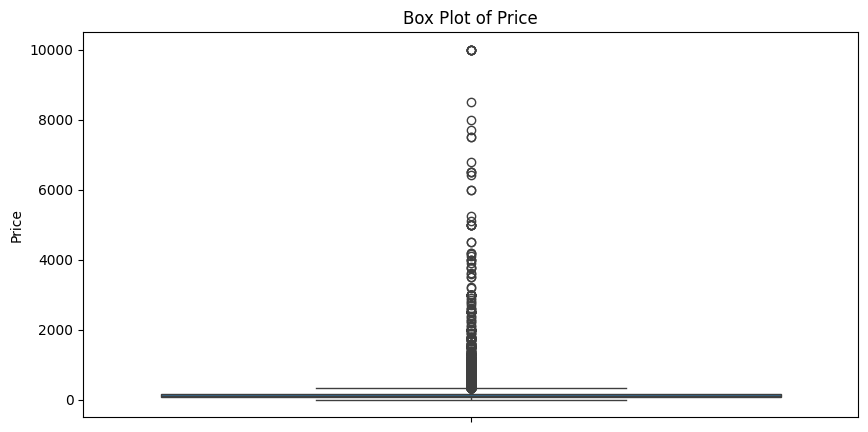

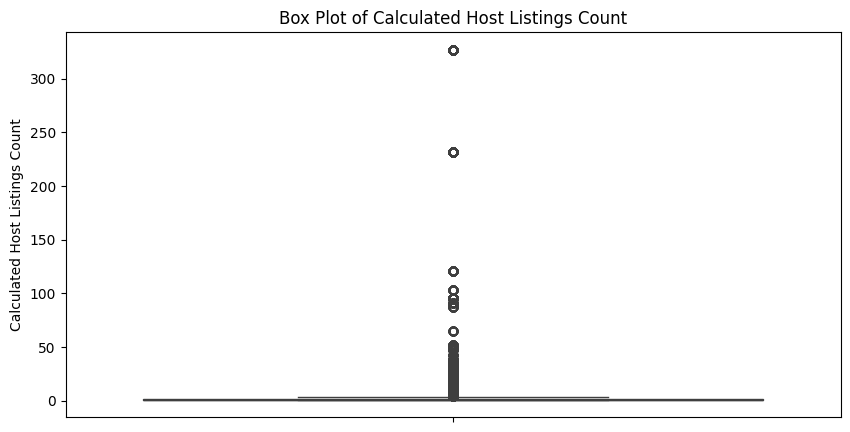

In [29]:
# put your answer here

# checking outlier box plot for 'price'
plt.figure(figsize=(10, 5))
sns.boxplot(y=df['price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.show()

# checking outlier box plot for 'calculated_host_listings_count'
plt.figure(figsize=(10, 5))
sns.boxplot(y=df['calculated_host_listings_count'])
plt.title('Box Plot of Calculated Host Listings Count')
plt.ylabel('Calculated Host Listings Count')
plt.show()

In [30]:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [31]:
df['calculated_host_listings_count'].describe()

,calculated_host_listings_count
count,48895.000000
mean,7.143982
std,32.952519
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,327.000000



Descriptive statistics after outlier handling:


,price,minimum_nights,calculated_host_listings_count
count,48884.000000,48884.000000,48884.000000
mean,143.988626,6.116480,7.144628
std,121.929660,9.244575,32.956185
min,10.000000,1.000000,1.000000
25%,69.000000,1.000000,1.000000
50%,106.000000,3.000000,1.000000
75%,175.000000,5.000000,2.000000
max,799.000000,45.000000,327.000000


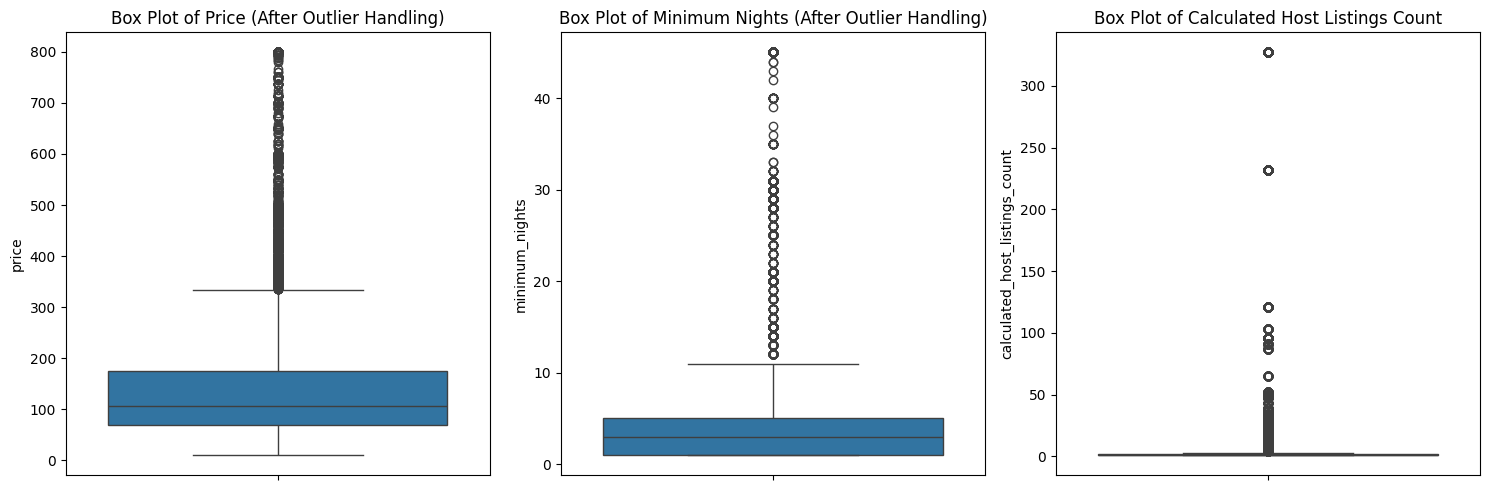

In [32]:
# handling invalid prices (price <= 0)
df = df[df['price'] > 0]

# handling high outliers in 'minimum_nights' by capping at the 99th percentile
min_nights_upper_bound = df['minimum_nights'].quantile(0.99)
df['minimum_nights'] = np.where(
    df['minimum_nights'] > min_nights_upper_bound,
    min_nights_upper_bound,
    df['minimum_nights']
)

# handling high outliers in 'price' by capping at the 99th percentile
price_upper_bound = df['price'].quantile(0.99)
df['price'] = np.where(
    df['price'] > price_upper_bound,
    price_upper_bound,
    df['price']
)

# for 'calculated_host_listings_count', we'll retain as is, acknowledging its
# skewed distribution and re-check descriptive statistics and box plots after
# handling outliers
print("\nDescriptive statistics after outlier handling:")
display(df[['price', 'minimum_nights', 'calculated_host_listings_count']].describe())

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['price'])
plt.title('Box Plot of Price (After Outlier Handling)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['minimum_nights'])
plt.title('Box Plot of Minimum Nights (After Outlier Handling)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['calculated_host_listings_count'])
plt.title('Box Plot of Calculated Host Listings Count')
plt.tight_layout()
plt.show()

## D. Enriching

Create at least 3 new variables:
- price_per_minimum_night
- review_rate_per_month (combine ratings + frequency)
- is_expensive (boolean flag based on price threshold)


In [33]:
# put your answer here

# creation of 'price_per_minimum_night'
df['price_per_minimum_night'] = df['price'] / df['minimum_nights']

# creation of 'review_rate_per_month' (combining frequency and total reviews)
max_reviews = df['number_of_reviews'].max()
if max_reviews == 0:
    df['review_rate_per_month'] = df['reviews_per_month']
else:
    df['review_rate_per_month'] = df['reviews_per_month'] * (1 + df['number_of_reviews'] / max_reviews)

# creation 'is_expensive' (boolean flag based on price threshold)
price_threshold = df['price'].quantile(0.75)
df['is_expensive'] = df['price'] > price_threshold

print("New variables created. Displaying head with new columns:")
display(df[['price', 'minimum_nights', 'price_per_minimum_night',
            'number_of_reviews', 'reviews_per_month', 'review_rate_per_month',
            'is_expensive']].head())

New variables created. Displaying head with new columns:


,price,minimum_nights,price_per_minimum_night,number_of_reviews,reviews_per_month,review_rate_per_month,is_expensive
0,149.0,1.0,149.0,9,0.21,0.213005,False
1,225.0,1.0,225.0,45,0.38,0.407186,True
2,150.0,3.0,50.0,0,0.00,0.000000,False
3,89.0,1.0,89.0,270,4.64,6.631733,False
4,80.0,10.0,8.0,9,0.10,0.101431,False


Create 1 aggregated summary table

(e.g. average price per neighborhood number of hosts per borough)

In [34]:
# put your answer here

aggregated_data = df.groupby('neighbourhood_group').agg(
    average_price=('price', 'mean'),
    average_minimum_nights=('minimum_nights', 'mean'),
    total_unique_hosts=('host_id', 'nunique')
).reset_index()

print("Aggregated Summary Table (Average Price, Average Minimum Nights, and Unique Hosts per Neighbourhood Group):")
display(aggregated_data)

Aggregated Summary Table (Average Price, Average Minimum Nights, and Unique Hosts per Neighbourhood Group):


/tmp/ipython-input-3020999335.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_data = df.groupby('neighbourhood_group').agg(


,neighbourhood_group,average_price,average_minimum_nights,total_unique_hosts
0,Bronx,85.831193,3.723853,789
1,Brooklyn,119.422742,5.322518,15965
2,Manhattan,182.961080,7.379640,16577
3,Queens,96.095305,4.704906,3983
4,Staten Island,101.798928,3.973190,256


## E. Validating

Create at least 3 validation checks
- Price must be positive.
- Host ID should not be null.
- Minimum nights must be ≥ 1.
- Generate a validation report:
- Count of rows violating each rule.

Decide if invalid rows (if any) should be removed or corrected?

In [35]:
# put your answer here

#  Validation Checks
validation_report = {}

# Rule 1: Price must be positive
violations_price_positive = df[df['price'] <= 0]
validation_report['Price <= 0'] = len(violations_price_positive)

# Rule 2: Host ID should not be null
violations_host_id_null = df[df['host_id'].isnull()]
validation_report['Host ID is null'] = len(violations_host_id_null)

# Rule 3: Minimum nights must be >= 1
violations_min_nights_less_than_1 = df[df['minimum_nights'] < 1]
validation_report['Minimum nights < 1'] = len(violations_min_nights_less_than_1)

print("\nValidation Report")
for rule, count in validation_report.items():
    print(f"Rule: '{rule}'\nViolating Rows: {count}\n")

if any(count > 0 for count in validation_report.values()):
    print("Unexpected violations found. These rows are considered invalid and will be removed.")
    df = df[df['price'] > 0]
    df = df[df['host_id'].notnull()]
    df = df[df['minimum_nights'] >= 1]
    print("Invalid rows (if any were found) have been removed.")
else:
    print("All validation checks passed. No violating rows found (as expected due to prior cleaning).")

print(f"\nDataFrame shape after validation: {df.shape}")


Validation Report
Rule: 'Price <= 0'
Violating Rows: 0

Rule: 'Host ID is null'
Violating Rows: 0

Rule: 'Minimum nights < 1'
Violating Rows: 0

All validation checks passed. No violating rows found (as expected due to prior cleaning).

DataFrame shape after validation: (48884, 20)


## F. Publishing

Select final columns for publication.



In [39]:
# put your answer here

# Define the list of final columns for publication
final_columns = [
    'id',
    'name',
    'host_id',
    'host_name',
    'neighbourhood_group',
    'neighbourhood',
    'latitude',
    'longitude',
    'room_type',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'has_reviews', # our derived flag
    'price_per_minimum_night', # our derived feature
    'review_rate_per_month', # our derived feature
    'is_expensive' # our derived feature
]

# Select only the final columns
df_cleaned = df[final_columns]

print("Selected final columns for publication. Displaying the head of the new DataFrame:")
display(df_cleaned.head())

Selected final columns for publication. Displaying the head of the new DataFrame:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,price_per_minimum_night,review_rate_per_month,is_expensive
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9,0.21,6,365,True,149.0,0.213005,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45,0.38,2,355,True,225.0,0.407186,True
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0,0.00,1,365,False,50.0,0.000000,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270,4.64,1,194,True,89.0,6.631733,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9,0.10,1,0,True,8.0,0.101431,False


Export cleaned dataset as "cleaned_airbnb.csv"

In [40]:
# put your answer here

df_cleaned.to_csv('cleaned_airbnb.csv', index=False)

print("Cleaned dataset exported successfully as 'cleaned_airbnb.csv'")

Cleaned dataset exported successfully as 'cleaned_airbnb.csv'


Export summary reports (e.g., validation or aggregations) as CSV.

In [41]:
# put your answer here

aggregated_data.to_csv('aggregated_airbnb_summary.csv', index=False)
print("Aggregated summary exported successfully as 'aggregated_airbnb_summary.csv'")

validation_report_df = pd.DataFrame(validation_report.items(), columns=['Validation Rule', 'Violating Rows'])
validation_report_df.to_csv('validation_report.csv', index=False)
print("Validation report exported successfully as 'validation_report.csv'")

Aggregated summary exported successfully as 'aggregated_airbnb_summary.csv'
Validation report exported successfully as 'validation_report.csv'
